 Proyecto de Ciencia de Datos
Integrantes: Otto Ferrer y Gema Zambrano

# Configuracion e Importacion de librerias

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

pd.set_option('display.max_columns', None)

# Carga de Datos

La carga de los dos conjuntos de datos ubicados en el repositorio:

**Datos Clínicos:** Contiene la información de las imágenes y diagnósticos.

**Datos Demográficos:** Contiene la información de raza, etnia y género del paciente.

In [78]:
url_chexpert = "https://github.com/ottoferrer/patient_data/raw/main/train_visualCheXbert.csv"
dataset = pd.read_csv(url_chexpert)

display(dataset.head())
display(dataset.info())

url_demo = 'https://github.com/ottoferrer/patient_data/raw/main/CHEXPERT%20DEMO.xlsx'
dataset_demo = pd.read_excel(url_demo, engine='openpyxl')

display(dataset_demo.head())
display(dataset_demo.info())

,Path,Sex,Age,Frontal/Lateral,AP/PA,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,No Finding
0,CheXpert-v1.0/train/patient00001/study1/view1_...,Female,68,Frontal,AP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,CheXpert-v1.0/train/patient00002/study2/view1_...,Female,87,Frontal,AP,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,CheXpert-v1.0/train/patient00002/study1/view1_...,Female,83,Frontal,AP,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
3,CheXpert-v1.0/train/patient00002/study1/view2_...,Female,83,Lateral,NaN,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
4,CheXpert-v1.0/train/patient00003/study1/view1_...,Male,41,Frontal,AP,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223414 entries, 0 to 223413
Data columns (total 19 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Path                        223414 non-null  object 
 1   Sex                         223414 non-null  object 
 2   Age                         223414 non-null  int64  
 3   Frontal/Lateral             223414 non-null  object 
 4   AP/PA                       191027 non-null  object 
 5   Enlarged Cardiomediastinum  223414 non-null  float64
 6   Cardiomegaly                223414 non-null  float64
 7   Lung Opacity                223414 non-null  float64
 8   Lung Lesion                 223414 non-null  float64
 9   Edema                       223414 non-null  float64
 10  Consolidation               223414 non-null  float64
 11  Pneumonia                   223414 non-null  float64
 12  Atelectasis                 223414 non-null  float64
 13  Pneumothorax  

None

,PATIENT,GENDER,AGE_AT_CXR,PRIMARY_RACE,ETHNICITY
0,patient24428,Male,61,White,Non-Hispanic/Non-Latino
1,patient48289,Female,39,Other,Hispanic/Latino
2,patient33856,Female,81,White,Non-Hispanic/Non-Latino
3,patient41673,Female,42,Unknown,Unknown
4,patient48493,Male,71,White,Non-Hispanic/Non-Latino


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65401 entries, 0 to 65400
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   PATIENT       65401 non-null  object
 1   GENDER        65401 non-null  object
 2   AGE_AT_CXR    65401 non-null  int64 
 3   PRIMARY_RACE  64860 non-null  object
 4   ETHNICITY     65317 non-null  object
dtypes: int64(1), object(4)
memory usage: 2.5+ MB


None

# Limpieza y unificacion de datos

Procesamiento de la columna 'Path' para extraer identificadores, estandarización de nombres de columnas y unión (merge) de ambas bases de datos. Se eliminan registros con valores nulos para el análisis.

In [79]:
#Preprocesamiento y Unificacion

dataset[['version', 'split', 'Patient_id', 'Study', 'Image']] = dataset['Path'].str.split('/', expand=True)

# Renombrar columnas demográficas para estandarizar con el dataset principal
dataset_demo = dataset_demo.rename(columns={
    'PATIENT': 'Patient_id',
    'PRIMARY_RACE': 'Race',
    'GENDER': 'Sex',
    'AGE_AT_CXR': 'Age',
    'ETHNICITY': 'Ethnicity'
})

# Eliminar columnas redundantes (Sex, Age) del demo dataset antes de unir
dataset_demo_clean = dataset_demo.drop(['Sex', 'Age'], axis=1)

# Unir datasets (Left Join sobre Patient_id)
final_dataset = pd.merge(dataset, dataset_demo_clean, on='Patient_id', how='left')

# Limpieza de valores nulos
final_dataset_clean = final_dataset.dropna().copy()

print(f"Dimensiones del dataset limpio: {final_dataset_clean.shape}")
display(final_dataset_clean.head())

Dimensiones del dataset limpio: (188828, 26)


,Path,Sex,Age,Frontal/Lateral,AP/PA,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,No Finding,version,split,Patient_id,Study,Image,Race,Ethnicity
0,CheXpert-v1.0/train/patient00001/study1/view1_...,Female,68,Frontal,AP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,CheXpert-v1.0,train,patient00001,study1,view1_frontal.jpg,Other,Non-Hispanic/Non-Latino
1,CheXpert-v1.0/train/patient00002/study2/view1_...,Female,87,Frontal,AP,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,CheXpert-v1.0,train,patient00002,study2,view1_frontal.jpg,"White, non-Hispanic",Non-Hispanic/Non-Latino
2,CheXpert-v1.0/train/patient00002/study1/view1_...,Female,83,Frontal,AP,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,CheXpert-v1.0,train,patient00002,study1,view1_frontal.jpg,"White, non-Hispanic",Non-Hispanic/Non-Latino
4,CheXpert-v1.0/train/patient00003/study1/view1_...,Male,41,Frontal,AP,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CheXpert-v1.0,train,patient00003,study1,view1_frontal.jpg,"White, non-Hispanic",Non-Hispanic/Non-Latino
5,CheXpert-v1.0/train/patient00004/study1/view1_...,Female,20,Frontal,PA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,CheXpert-v1.0,train,patient00004,study1,view1_frontal.jpg,Black or African American,Non-Hispanic/Non-Latino


# Estandarización de Variables Demográficas (Raza y Etnia)

Normalización de las categorías de raza y etnia, agrupando textos similares y corrigiendo inconsistencias en la entrada de datos.

In [80]:
# Estandarización de Variables Categóricas

# Estandarización de RAZA (Race)
# Limpieza inicial de texto (minúsculas y espacios)
final_dataset_clean["race_raw_clean"] = final_dataset_clean["Race"].str.lower().str.strip()
final_dataset_clean["race_standardized"] = "Unknown / Not Reported"  # Valor por defecto

# Reglas de agrupación
final_dataset_clean.loc[final_dataset_clean["race_raw_clean"].str.contains("white|caucasian", na=False), "race_standardized"] = "White"
final_dataset_clean.loc[final_dataset_clean["race_raw_clean"].str.contains("black|african", na=False), "race_standardized"] = "Black or African American"
final_dataset_clean.loc[final_dataset_clean["race_raw_clean"].str.contains("asian", na=False), "race_standardized"] = "Asian"
final_dataset_clean.loc[final_dataset_clean["race_raw_clean"].str.contains("american indian|native american|alaska", na=False), "race_standardized"] = "American Indian or Alaska Native"
final_dataset_clean.loc[final_dataset_clean["race_raw_clean"].str.contains("hawaiian|pacific islander", na=False), "race_standardized"] = "Native Hawaiian or Other Pacific Islander"
final_dataset_clean.loc[final_dataset_clean["race_raw_clean"].str.contains("^other", regex=True, na=False), "race_standardized"] = "Other"

# Mostrar distribución
print("Distribución de Raza Estandarizada:")
display(final_dataset_clean['race_standardized'].value_counts().to_frame())

# Estandarización de ETNIA (Ethnicity)
final_dataset_clean["ethnicity_clean"] = final_dataset_clean["Ethnicity"].str.lower().str.strip()
final_dataset_clean["ethnicity_standardized"] = "Unknown / Not Reported"

# Reglas de agrupación
mask_hispanic = final_dataset_clean["ethnicity_clean"].str.contains("hispanic|latino", na=False)
mask_non_hispanic = final_dataset_clean["ethnicity_clean"].str.contains("non-hispanic|not hispanic", na=False)

final_dataset_clean.loc[mask_non_hispanic, "ethnicity_standardized"] = "Non-Hispanic"
final_dataset_clean.loc[mask_hispanic & ~mask_non_hispanic, "ethnicity_standardized"] = "Hispanic / Latino"

# Mostrar distribución
print("Distribución de Etnia Estandarizada:")
display(final_dataset_clean["ethnicity_standardized"].value_counts().to_frame())

Distribución de Raza Estandarizada:


,count
race_standardized,
White,107479
Other,26933
Unknown / Not Reported,21769
Asian,19649
Black or African American,10053
Native Hawaiian or Other Pacific Islander,2486
American Indian or Alaska Native,459


Distribución de Etnia Estandarizada:


,count
ethnicity_standardized,
Non-Hispanic,138145
Unknown / Not Reported,28630
Hispanic / Latino,22053


##Cuantificación de Ruido y Calidad del Dato


Cuantificar el "ruido" presente en el dataset procesado. Definimos ruido como aquella información que, aunque está presente estructuralmente, carece de valor analítico para nuestras preguntas de negocio.
Se evalúan dos dimensiones:

**Ruido Demográfico:** Proporción de registros donde la variable race_standardized fue marcada como "Unknown" o "Not Reported", lo cual limita la segmentación poblacional.

**Ruido Clínico:** Proporción de estudios etiquetados como "No Finding", que representan imágenes sin patologías detectables.

In [81]:
# --- Cuantificación de Ruido y Calidad del Dato ---

total_registros = len(final_dataset_clean)

# 1. Ruido Demográfico: Proporción de raza desconocida
ruido_demo = final_dataset_clean['race_standardized'].str.contains('Unknown', case=False, na=False).sum()
pct_ruido_demo = (ruido_demo / total_registros) * 100

# 2. Ruido Clínico: Proporción de imágenes sin hallazgos ('No Finding')
if 'No Finding' in final_dataset_clean.columns:
    ruido_clinico = (final_dataset_clean['No Finding'] == 1).sum()
    pct_ruido_clinico = (ruido_clinico / total_registros) * 100
else:
    pct_ruido_clinico = 0

# Creación de tabla resumen
tabla_calidad = pd.DataFrame({
    'Indicador': ['Total Registros', 'Ruido Demográfico (Raza Desconocida)', 'Ruido Clínico (Sin Hallazgos)'],
    'Valor': [total_registros, f"{pct_ruido_demo:.2f}%", f"{pct_ruido_clinico:.2f}%"]
})

print("--- REPORTE DE CALIDAD DE DATOS ---")
display(tabla_calidad)

--- REPORTE DE CALIDAD DE DATOS ---


,Indicador,Valor
0,Total Registros,188828
1,Ruido Demográfico (Raza Desconocida),11.53%
2,Ruido Clínico (Sin Hallazgos),12.80%


##Ingeniería de Características: Índice de Carga Patológica

Para profundizar el análisis más allá del diagnóstico binario, generamos una nueva métrica denominada **Pathology Burden Index** (Índice de Carga Patológica).[link text](https://academic.oup.com/eurpub/article/29/1/182/5033670?login=false)

Esta métrica se fundamenta en literatura sobre radiología torácica, donde la **co-ocurrencia de hallazgos** (comorbilidad) es un indicador clave de la complejidad del paciente. Sumamos los hallazgos positivos para categorizar a los pacientes en tres niveles de severidad: Sano, Leve y Severo.

In [82]:
# --- Ingeniería de Características ---

# Lista de patologías a analizar
patologias = [
    'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion',
    'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax',
    'Pleural Effusion', 'Pleural Other', 'Fracture'
]

# 1. Conversión a numérico y llenado de nulos con 0
for col in patologias:
    if col in final_dataset_clean.columns:
        final_dataset_clean[col] = pd.to_numeric(final_dataset_clean[col], errors='coerce').fillna(0)

# 2. Cálculo de la carga patológica (Suma de hallazgos positivos)
final_dataset_clean['Pathology_Burden'] = final_dataset_clean[patologias].sum(axis=1)

# 3. Categorización en niveles de severidad
# Sano: 0 | Leve/Moderado: 1-2 | Severo: >2
final_dataset_clean['Burden_Category'] = pd.cut(
    final_dataset_clean['Pathology_Burden'],
    bins=[-1, 0, 2, 20],
    labels=['Sano', 'Leve/Mod', 'Severo']
)

print("Distribución de Carga Patológica:")
display(final_dataset_clean['Burden_Category'].value_counts(normalize=True).to_frame())

Distribución de Carga Patológica:


,proportion
Burden_Category,
Severo,0.733525
Sano,0.180233
Leve/Mod,0.086243


In [83]:
#ANÁLISIS DESCRIPTIVO

print("--- Resumen Estadístico de Variables Numéricas ---")
tabla_estadistica = final_dataset_clean[['Age', 'Pathology_Burden']].describe()

display(tabla_estadistica)

print("\n--- Interpretación Rápida ---")
print(f"Edad Promedio: {tabla_estadistica.loc['mean', 'Age']:.1f} años")
print(f"Carga Patológica Máxima detectada: {tabla_estadistica.loc['max', 'Pathology_Burden']:.0f} patologías simultáneas")

--- Resumen Estadístico de Variables Numéricas ---


,Age,Pathology_Burden
count,188828.000000,188828.000000
mean,60.870003,4.888136
std,17.911493,3.052144
min,18.000000,0.000000
25%,50.000000,2.000000
50%,62.000000,6.000000
75%,74.000000,7.000000
max,110.000000,12.000000



--- Interpretación Rápida ---
Edad Promedio: 60.9 años
Carga Patológica Máxima detectada: 12 patologías simultáneas


##Visualización Analítica y Respuesta a Preguntas de Negocio


Empleamos visualizaciones avanzadas para responder las interrogantes planteadas sobre patrones epidemiológicos y sesgos:

**Matriz de Correlación:** Analizamos la co-ocurrencia de enfermedades. ¿Si un paciente tiene Edema, es probable que tenga Cardiomegalia?

**Faceted Plot:** Desglosamos la prevalencia de **Edema Pulmonar**, controlando simultáneamente por edad y sexo, cumpliendo con el requerimiento de análisis multidimensional.

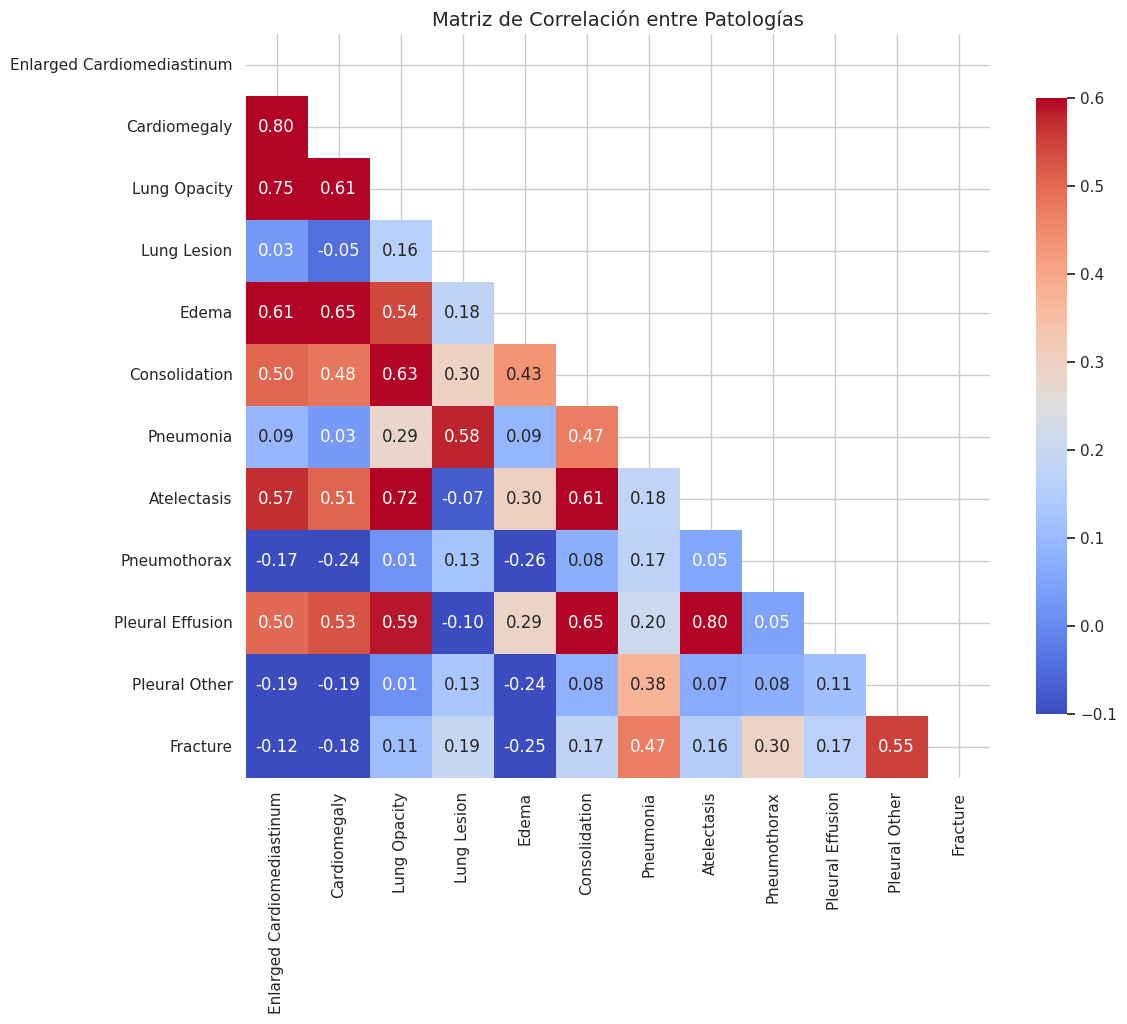

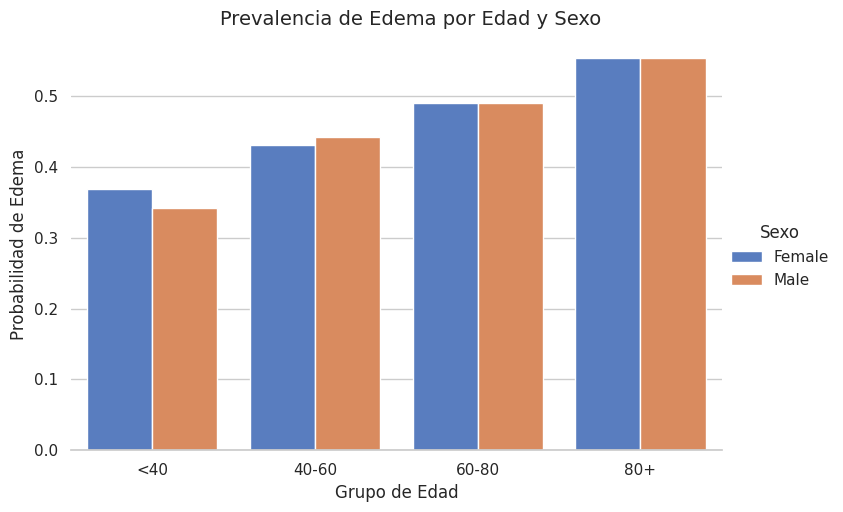

<Figure size 1200x600 with 0 Axes>

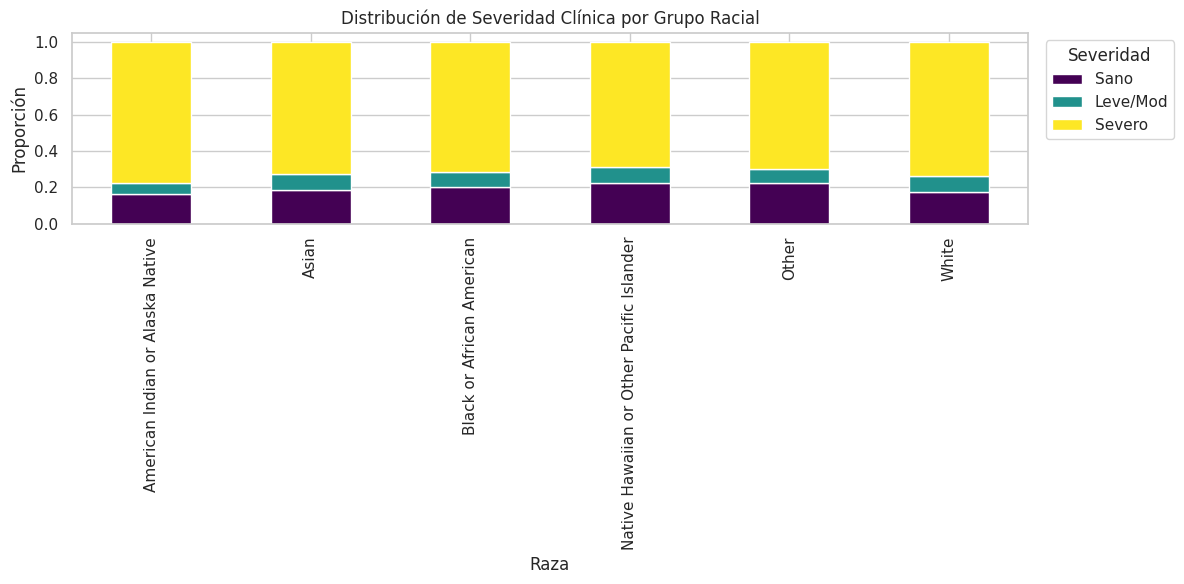

In [84]:
# --- Visualización de Resultados ---

# GRÁFICO 1: Matriz de Correlación (Co-ocurrencia)
plt.figure(figsize=(12, 10))
corr_matrix = final_dataset_clean[patologias].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Ocultar triangular superior

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-0.1, vmax=0.6, square=True, cbar_kws={"shrink": .8})
plt.title('Matriz de Correlación entre Patologías', fontsize=14)
plt.show()

# GRÁFICO 2: Faceted Plot (Edema por Edad y Sexo)
# Preparación de datos: asegurar edad numérica y crear grupos
final_dataset_clean['Age'] = pd.to_numeric(final_dataset_clean['Age'], errors='coerce')
final_dataset_clean['Age_Group'] = pd.cut(final_dataset_clean['Age'],
                                          bins=[0, 40, 60, 80, 120],
                                          labels=['<40', '40-60', '60-80', '80+'])

g = sns.catplot(
    data=final_dataset_clean, kind="bar",
    x="Age_Group", y="Edema", hue="Sex",
    palette="muted", height=5, aspect=1.5,
    errorbar=None
)
g.despine(left=True)
g.set_axis_labels("Grupo de Edad", "Probabilidad de Edema")
g._legend.set_title("Sexo")
g.figure.suptitle('Prevalencia de Edema por Edad y Sexo', y=1.02, fontsize=14)
plt.show()

# GRÁFICO 3: Disparidad Racial (Severidad Clínica)
plt.figure(figsize=(12, 6))
# Filtrar datos desconocidos para limpieza visual
df_viz = final_dataset_clean[~final_dataset_clean['race_standardized'].str.contains('Unknown', case=False, na=True)]

# Tabla cruzada normalizada
cross_tab = pd.crosstab(df_viz['race_standardized'], df_viz['Burden_Category'], normalize='index')

# Gráfico de barras apiladas
cross_tab.plot(kind='bar', stacked=True, colormap='viridis', figsize=(12, 6))
plt.title('Distribución de Severidad Clínica por Grupo Racial')
plt.xlabel('Raza')
plt.ylabel('Proporción')
plt.legend(title='Severidad', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()